# Verifying Sparse Results Against Dense Results
We have crated sparsely computed tensors using a sparse implementation of cupy.
To verify if the results are similar to the dense implementation, we load both sparse and dense tensors and compare their values.


In [10]:
from tucker_tensor import TuckerDecomposition
dataset = "fineweb_sparse"
dims = 1000
rank = 100
iterations = 1000

In [11]:
from utils import select_gpu
select_gpu(3)

device(type='cuda', index=3)

In [16]:
sparse_counting = TuckerDecomposition.load_from_disk(
    dataset=dataset,
    method="counting",
    dims=dims,
    rank=rank,
    iterations=iterations,
    map_location="cpu"
)

In [17]:
dense_counting = TuckerDecomposition.load_from_disk(
    dataset="fineweb_dutch_vectors_ids",
    method="counting",
    dims=dims,
    rank=rank,
    iterations=iterations,
    map_location="cpu"
)

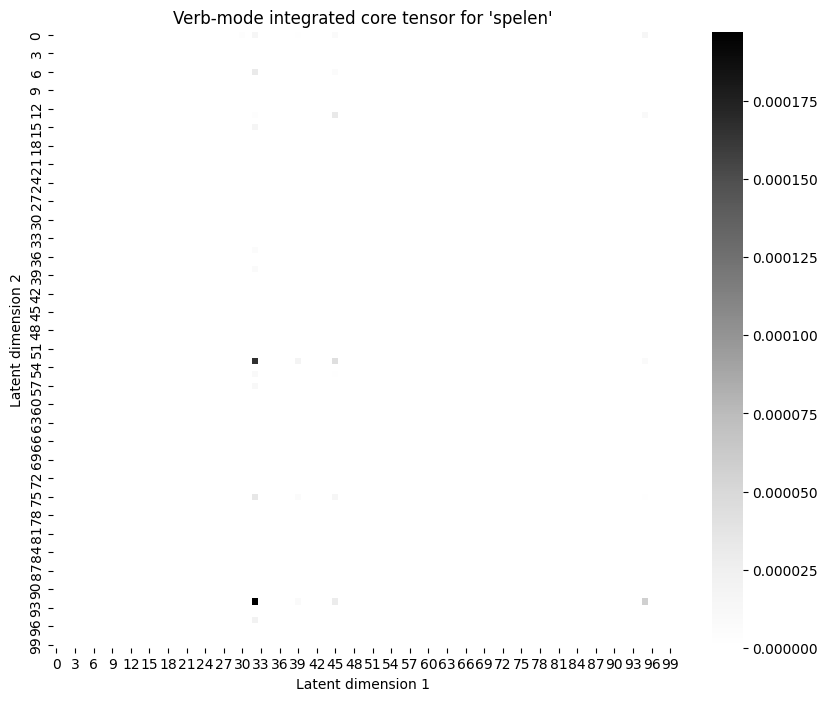

In [18]:
triple = ("spelen", "meisje", "spel")
sparse_counting.visualize_slice(triple, role="verb", method="weighted_tuple")

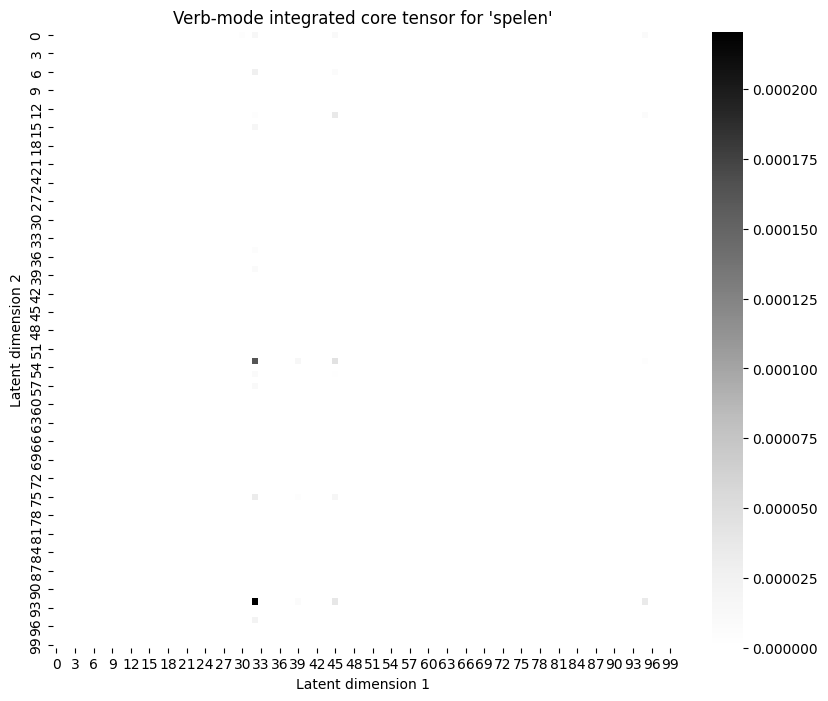

In [19]:
dense_counting.visualize_slice(triple, role="verb", method="weighted_tuple")

Method: counting


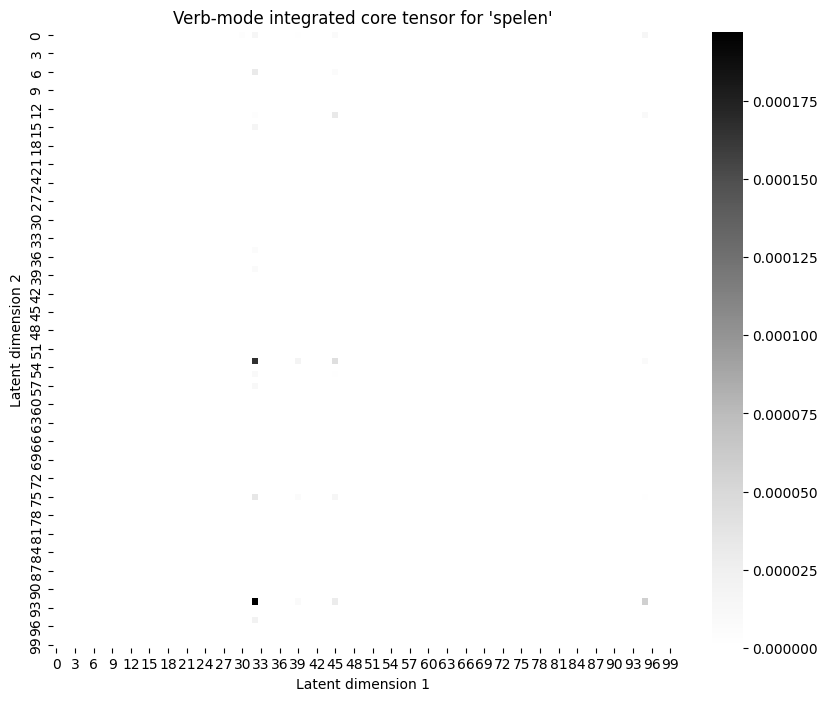

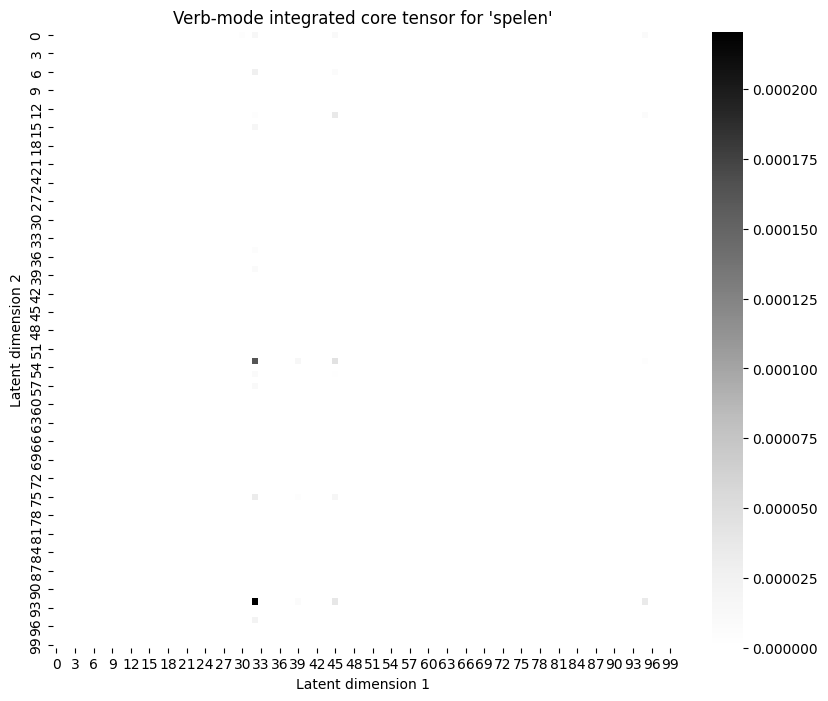

Score sparse: 0.0008326576207764447, Score dense: 0.0008157450356520712
Difference = 1.6912585124373436e-05
Top words sparse: [('gebruiken', 0.6794751882553101), ('maken', 0.24421821534633636), ('geboren', 0.17406421899795532), ('Lees', 0.1672135293483734), ('baseren', 0.16574743390083313)]
Top words dense: [('gebruiken', 9.433923651158693e-07), ('maken', 3.395718692900118e-07), ('geboren', 2.4160658540495206e-07), ('Lees', 2.326086843140729e-07), ('baseren', 2.3087461897830508e-07)]
Method: sc


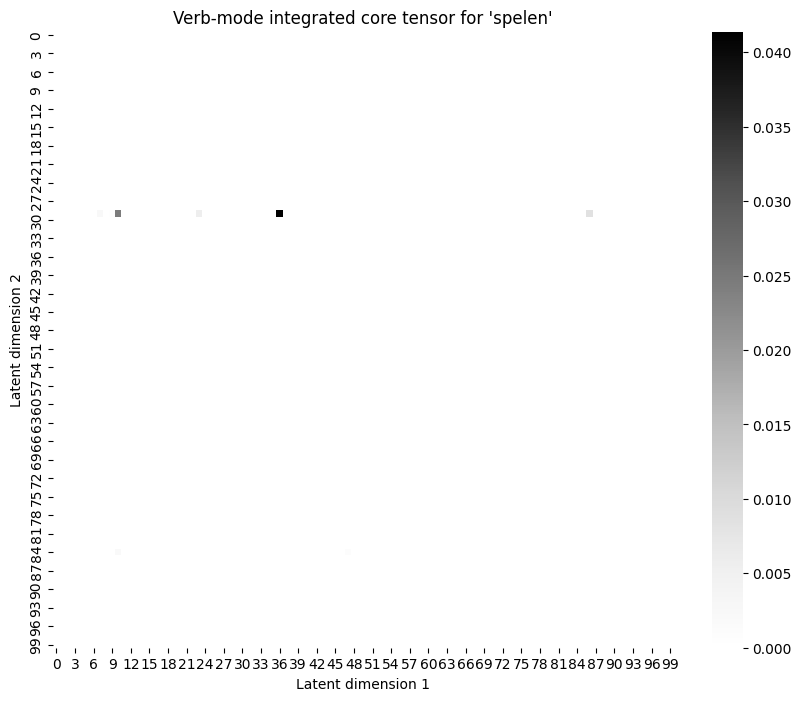

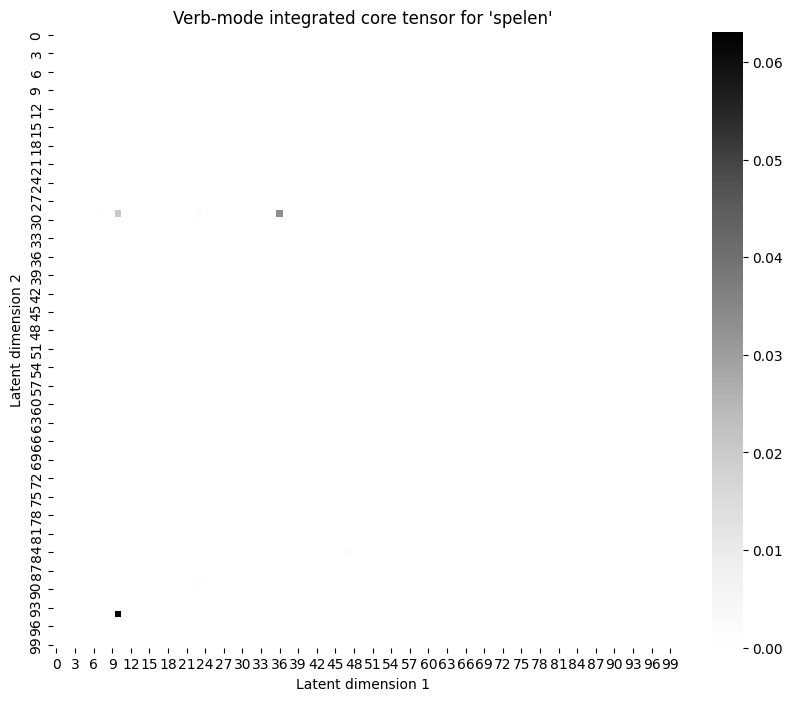

Score sparse: 0.08731985092163086, Score dense: 0.1253853589296341
Difference = 0.038065508008003235
Top words sparse: [('bepalen', 0.5632831454277039), ('identificeren', 0.42501258850097656), ('stellen', 0.3436049520969391), ('evalueren', 0.28856778144836426), ('beoordelen', 0.2786226272583008)]
Top words dense: [('bepalen', 1.9814262941508787e-06), ('identificeren', 1.516084921604488e-06), ('stellen', 1.295766423936584e-06), ('achterhalen', 9.685265922598774e-07), ('evalueren', 9.616795750844176e-07)]
Method: sii


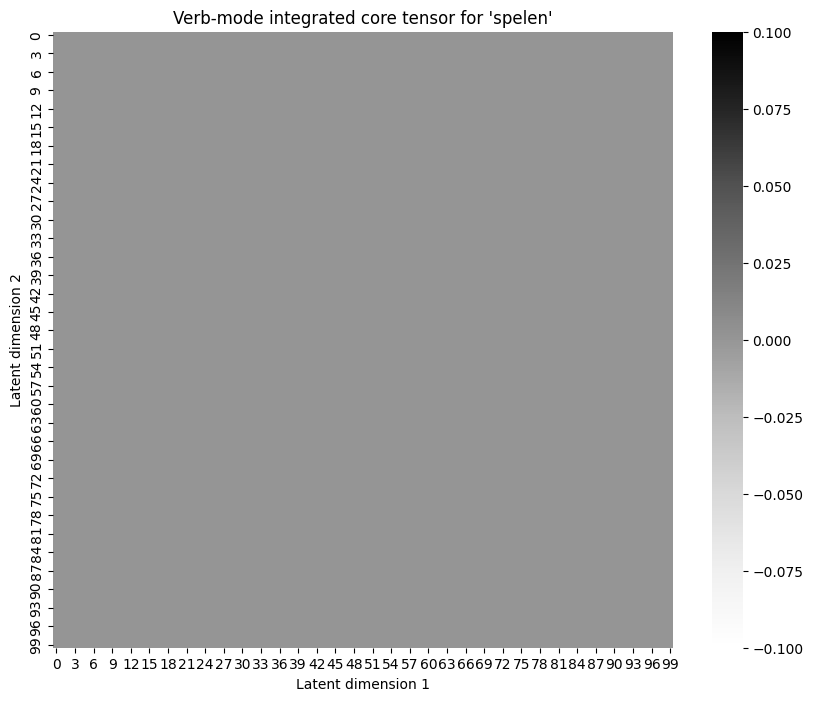

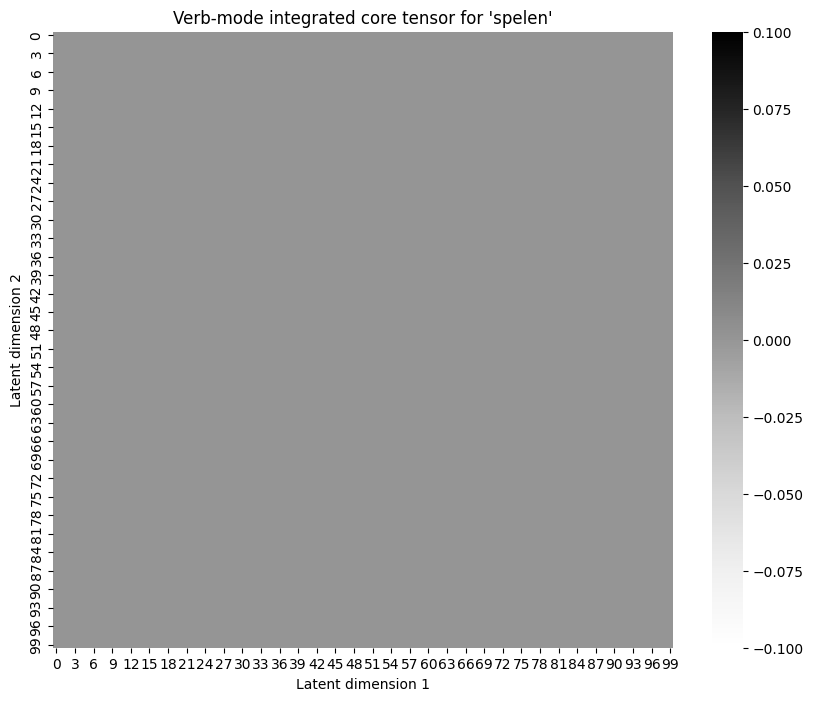

Score sparse: 0.0, Score dense: 0.0
Difference = 0.0
Top words sparse: [('aanpassen', 0.1733730137348175), ('verminderen', 0.16722269356250763), ('onthullen', 0.16013838350772858), ('oplossen', 0.15977628529071808), ('benaderen', 0.1597728580236435)]
Top words dense: [('voorschrijven', 5.507712064201087e-10), ('adviseren', 4.4714629403176875e-18), ('voorstellen', 9.265984844629293e-25), ('aanbevelen', 2.5828117084554107e-25), ('beoordelen', 2.5328873441398565e-27)]


In [25]:
for method in ["counting", "sc", "sii"]:
    print(f"Method: {method}")
    tensor_sparse = TuckerDecomposition.load_from_disk(
    dataset=dataset,
    method=method,
    dims=dims,
    rank=rank,
    iterations=iterations,
    map_location="cpu")
    tensor_dense = TuckerDecomposition.load_from_disk(
        dataset="fineweb_dutch_vectors_ids",
        method=method,
        dims=dims,
        rank=rank,
        iterations=iterations,
        map_location="cpu"
    )
    slice_sparse = tensor_sparse.visualize_slice(triple, role="verb", method="weighted_tuple")
    slice_dense = tensor_dense.visualize_slice(triple, role="verb", method="weighted_tuple")
    score_sparse = tensor_sparse.score_scalar(triple)
    score_dense = tensor_dense.score_scalar(triple)
    print(f"Score sparse: {score_sparse}, Score dense: {score_dense}")
    print(f"Difference = {abs(score_sparse - score_dense)}")
    highest_sparse = tensor_sparse.get_top_words_for_dimension("verb", 3, 5)
    highest_dense = tensor_dense.get_top_words_for_dimension("verb", 3, 5)
    print(f"Top words sparse: {highest_sparse[:5]}")
    print(f"Top words dense: {highest_dense[:5]}")

In [30]:
# we visualize a few more dimensions
for method in ["counting", "sc", "sii"]:
    print(f"Method: {method}")
    tensor_sparse = TuckerDecomposition.load_from_disk(
    dataset=dataset,
    method=method,
    dims=dims,
    rank=rank,
    iterations=iterations,
    map_location="cpu")
    tensor_dense = TuckerDecomposition.load_from_disk(
        dataset="fineweb_dutch_vectors_ids",
        method=method,
        dims=dims,
        rank=rank,
        iterations=iterations,
        map_location="cpu"
    )
    for dim in [0, 1, 2, 4, 5]:
        print(f"Dimension: {dim}")
        highest_sparse = tensor_sparse.get_top_words_for_dimension("verb", dim, 5)
        highest_dense = tensor_dense.get_top_words_for_dimension("verb", dim, 5)
        # we check if the words are the same
        list_sparse = [word for word, score in highest_sparse]
        list_dense = [word for word, score in highest_dense]
        if not list_sparse == list_dense:
            print("The top words are different!")
            print(f"Top words sparse: {highest_sparse}")
            print(f"Top words dense: {highest_dense}\n")
        else:
            print(f"Top words sparse and dense are the same: {highest_sparse}\n")

    print("-----------------------------------")


Method: counting
Dimension: 0
Top words sparse and dense are the same: [('gebruiken', 0.59892737865448), ('blijken', 0.2739701569080353), ('aanbevelen', 0.17803426086902618), ('beschouwen', 0.14109914004802704), ('plaatsen', 0.13661770522594452)]

Dimension: 1
Top words sparse and dense are the same: [('uitvoeren', 0.3762117922306061), ('noemen', 0.25673341751098633), ('brengen', 0.19469022750854492), ('bouwen', 0.18877264857292175), ('vinden', 0.1824871301651001)]

Dimension: 2
Top words sparse and dense are the same: [('betekenen', 0.6553463935852051), ('komen', 0.461688756942749), ('leiden', 0.3823188543319702), ('gebeuren', 0.2582624852657318), ('helpen', 0.1850377768278122)]

Dimension: 4
The top words are different!
Top words sparse: [('gebruiken', 0.371215283870697), ('maken', 0.3113403916358948), ('blijken', 0.23627328872680664), ('uitvoeren', 0.23360377550125122), ('beschouwen', 0.22287330031394958)]
Top words dense: [('opnemen', 2.0384359231684357e-06), ('gebruiken', 3.215039

# We get more or less the same results

